This notebook creates leading-order sensitivity plots for Cliffordized cultivation circuits

In [39]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [40]:
import numpy as np
import stim
import re

import pygsti
import time
import itertools

from collections import Counter

import pygsti.tools.errgenproptools as eprop
from pygsti.errorgenpropagation.errorpropagator import ErrorGeneratorPropagator
from pygsti.errorgenpropagation.localstimerrorgen import LocalStimErrorgenLabel

from cultiv_circuits_cleaned import *
from error_models import *

from pygsti.modelmembers.operations import ComposedOp, LindbladErrorgen, ExpErrorgenOp
from pygsti.baseobjs import Label, QubitSpace

from matplotlib import pyplot as plt
import seaborn as sns

In [41]:
import pathlib
import sys

src_path = pathlib.Path('../cultivation/cultivation-paper-code/code/src')
assert src_path.exists()
sys.path.append(str(src_path))

import cultiv
import gen

In [42]:
from pygsti.extras.dem_construction import pygsti_object_builders as obj
from pygsti.extras.dem_construction import helper_functions as helper
from pygsti.extras.dem_construction import sensitivity_analysis as sensitivity
from pygsti.extras.dem_construction import dem_tools as dems

In [5]:
cultiv_c_basic = create_d3_cultiv_circ()
cultiv_circuit = gen.transpile_to_z_basis_interaction_circuit(cultiv_c_basic) 
cultiv_c_basic =  cultiv.make_inject_and_cultivate_circuit(inject_style='unitary', basis='X', dcolor=3)
cultiv_circuit = gen.transpile_to_z_basis_interaction_circuit(cultiv_c_basic) 

In [43]:
? gen.transpile_to_z_basis_interaction_circuit

Signature:
 gen.transpile_to_z_basis_interaction_circuit(
    circuit: stim._stim_polyfill.Circuit,
    *,
    is_entire_circuit: bool = True,
) -> stim._stim_polyfill.Circuit
Docstring:
Converts to a circuit using CZ, ISWAP, and MZZ as appropriate.

This method mostly focuses on inserting single qubit rotations to convert
interactions into their Z basis variant. It also does some optimizations
that remove redundant rotations which would tend to be introduced by this
process.
File:      ~/Documents/dems_from_errorgens_cleaned_code/cultivation/cultivation-paper-code/code/src/gen/_layers/_transpile.py
Type:      function

In [6]:
def create_processor_spec(pcircuit, qubit_labels):
    """
    Creates a processor spec that from a pyGSTi syndrome extraction circuit, containing the 
    required gates (CNOTs between qubits that are coupled in those circuits). Will then be
    used to define the noise model we simulate.
    """
    ###Note to future self: watch out for the possibility of wanting other gates###
    pyg_cstr = pcircuit.str
    # Find all the CNOT gates used in the circuit, using brute force string comprehension
    cleaned_pcstr = pyg_cstr.replace(']', '').replace('[', '').split('@')[0]
    connections = [(int(s.split(':')[1]), int(s.split(':')[2])) for s in cleaned_pcstr.split('G') if len(s.split(':')) > 2]

    availability={'Gcphase':connections, 'Gcnot':connections}
    pspec = pygsti.processors.QubitProcessorSpec(len(qubit_labels), ['Gcphase', 'Gcnot' ,'Gh', 'Gypi2', 'Gympi2', 'Gxpi2', 'Gxpi', 'Gxmpi2', 'Gi', 'Gc0'], qubit_labels=qubit_labels,
                                             availability=availability)
    
    return pspec

In [7]:
error_rates_dict = make_h_param_vector(twoq_inf=0.01, oneq_inf=0.01, idle_inf=0.01)#TODO make H parameter vector #make_depol_error_param_vector(twoq_inf=0.001, oneq_inf=0.001, spam_error=0.001, idle_inf=0.001) #make_sh_error_param_dict(scale=1/2.2)
theta, parameter_indexing = helper.build_parameter_vector(error_rates_dict)

In [8]:
c, qubit_mapping, measurements, detectors = obj.stim_to_pygsti_circuit(cultiv_circuit, range(cultiv_circuit.num_qubits), qubit_relabelling_dict=None, show_qubit_mappings=False, include_idles=False, include_observables=True)

In [9]:
num_qubits = len(c.line_labels)
qubit_labels = range(num_qubits)
num_parameters = len(parameter_indexing)

In [11]:
pspec = create_processor_spec(c, qubit_labels)
twoq_gates = ['Gcphase']
oneq_gates = [g for g in pspec.gate_names if g != 'Gcphase' and g != 'Gcnot']

model = obj.build_model(error_rates_dict, pspec, oneq_gates, twoq_gates)
egp = ErrorGeneratorPropagator(model)

In [12]:
serial_c = c.serialize()

In [13]:
#propagating the errors to the end of the circuit
time1 = time.time()
mapping_to_eoc_eeg = egp.errorgen_transform_map(serial_c, include_spam=False)
time2 = time.time()
print('Errors propagated in {} seconds'.format(time2-time1))

Errors propagated in 0.032634735107421875 seconds


In [14]:
svs, s_svs = sensitivity.compute_sensitivity_vectors(mapping_to_eoc_eeg, egp, serial_c, parameter_indexing, return_s_equivalent=True)

In [15]:
stim_c_no_extras = obj.pygsti_c_to_stim(serial_c)

In [16]:
tableau = stim.Tableau.from_circuit(stim_c_no_extras, ignore_measurement=True) 
inverse_tableau = tableau.inverse()
sim = stim.TableauSimulator()
sim.set_inverse_tableau(inverse_tableau)

In [17]:
eoc_err = egp.propagate_errorgens_bch(serial_c, bch_order=1, include_spam=False)

In [18]:
dps = [dems.get_detector_as_parity(d, measurements, num_qubits) for d in detectors]

In [20]:
terms_by_effect = dems.sort_terms_by_effect(eoc_err, dps, sim)

In [21]:
channels_by_effect = {event:{eeg:eoc_err for eeg in terms} for event, terms in terms_by_effect.items()}

# Sensitivity Matrices

In [28]:
def sensitivity_matrix_plot(s_matrix, stochastic_s_vector, title="Sensitivity Matrix", filename=None):
    
    plt.figure(figsize=(5.2,1.5))
    x = [i for i in range(15)]
    plt.axhline(0,linestyle=":")
    plt.bar(x,[s_matrix[i,i] for i in range(15)], label='H error')
    plt.bar(x, [stochastic_s_vector[i,i] for i in range(15)], width=0.4, label='S error')
    plt.xticks(x, [r'$\theta_{{{}}}$'.format(p[1][1]) for p in parameter_indexing[-15:]], fontsize=9)
    plt.tight_layout()
    plt.legend(loc=(1.1,0), fontsize=12)
    if filename is None:
        plt.show()
    else:
        plt.savefig('barchart_'+filename)
    
    plt.figure()
    ax = sns.heatmap(s_matrix, #vmin=-50, vmax=450, 
                     cmap=sns.diverging_palette(220, 20, as_cmap=True),
                    cbar_kws={'label':'Parameter Sensitivity'}, center=0)
    plt.xticks(x, [r'$\theta_{{{}}}$'.format(p[1][1]) for p in parameter_indexing[-15:]], fontsize=9)
    plt.yticks(x, [r'$\theta_{{{}}}$'.format(p[1][1]) for p in parameter_indexing[-15:]], fontsize=9)
    #plt.axhline(3, ls=':', lw=0.5)
    #plt.axvline(3, ls=':', lw=0.5)
    plt.title(title, fontsize=12)
    plt.xlabel('CPHASE H Error Parameter', fontsize=12)
    plt.ylabel('CPHASE H Error Parameter', fontsize=12)
    if filename is None:
        plt.show()
    else:
        plt.savefig(filename)

In [77]:
def sensitivity_matrix_plot_small(s_matrix, stochastic_s_vector, title="Sensitivity Matrix", filename=None):
    
    plt.figure(figsize=(3.25,1))
    x = [i for i in range(15)]
    plt.axhline(0,linestyle=":")
    plt.bar(x,[s_matrix[-15+1*i,-15+1*i] for i in range(15)], label='H error')
    plt.bar(x, [stochastic_s_vector[-15+1*i,-15+1*i] for i in range(15)], width=0.4, label='S error')
    plt.xticks(x, [r'$\theta_{{{}}}$'.format(p[1][1]) for p in parameter_indexing[-15:]], fontsize=6)
    plt.yticks(fontsize=6)
    plt.tight_layout()
    plt.legend(loc=(1.1,0), fontsize=6)
    if filename is None:
        plt.show()
    else:
        plt.savefig('figures/bar_'+filename+'.pdf')
    
    plt.figure(figsize=(3.25,2.75))
    ax = sns.heatmap(s_matrix, #vmin=-50, vmax=450, 
                     cmap=sns.diverging_palette(220, 20, as_cmap=True),
                    cbar_kws={'label':'Parameter Sensitivity'}, center=0)
    colorbar = ax.collections[0].colorbar
    colorbar.ax.yaxis.label.set_size(6)  # Set the font size for the color bar label
    colorbar.ax.tick_params(labelsize=6)  # Set the font size for the tick labels

    plt.xticks(x, [r'$\theta_{{{}}}$'.format(p[1][1]) for p in parameter_indexing[-15:]], fontsize=6)
    plt.yticks(x, [r'$\theta_{{{}}}$'.format(p[1][1]) for p in parameter_indexing[-15:]], fontsize=6)
    #plt.axhline(3, ls=':', lw=0.5)
    #plt.axvline(3, ls=':', lw=0.5)
    plt.title(title, fontsize=8)
    plt.xlabel('CPHASE H Error Parameter', fontsize=6)
    plt.ylabel('CPHASE H Error Parameter', fontsize=6)
    if filename is None:
        plt.show()
    else:
        plt.savefig('figures/'+filename+'.pdf')

In [93]:
def compute_event_sensitivity_matrix(svs, egp, circuit, det_pauli, tableau, show_progress=False):
    
    mapping_to_eoc_eeg = egp.errorgen_transform_map(circuit, include_spam=False)
    eeg_terms = list(set(mapping_to_eoc_eeg.values()))
    n_params = len(theta)
    M = np.zeros(shape=(n_params, n_params))
    filtered_terms = []
    for j,eeg in enumerate(eeg_terms):
        P = eeg[0].basis_element_labels[0]
        if not P.commutes(det_pauli): 
            filtered_terms.append(eeg)
    
    if show_progress:
        print('filtered terms')
    sim = stim.TableauSimulator()
    sim.set_inverse_tableau(inverse_tableau)

    for j, (eeg1, eeg2) in enumerate(itertools.product(filtered_terms, repeat=2)):
        sv1 = svs[eeg1[0]]
        sv2 = svs[eeg2[0]]

        new_eeg = LocalStimErrorgenLabel('C',(eeg1[0].basis_element_labels[0], eeg2[0].basis_element_labels[0]))

        contribution = dems.compute_contribution(new_eeg, 1, det_pauli, sim)

        M_term = -1*contribution*sensitivity.create_sensitivity_matrix(sv1, sv2, n_params)/2 #contribution*

        M += M_term
    return M

In [79]:
def compute_postselect_sensitivity_matrix(svs, egp, circuit, dps, tableau, show_progress=False):
    '''
    compute a leading-order sensitivity matrix for observing no detection events (which results in retaining a shot in cultivation)
    this should just be the sum of the detector Paulis aside from the observable
    '''
    mapping_to_eoc_eeg = egp.errorgen_transform_map(circuit, include_spam=False)
    eeg_terms = list(set(v[0] for v in mapping_to_eoc_eeg.values()))
    n_params = len(theta)
    M = np.zeros(shape=(n_params, n_params))

    sim = stim.TableauSimulator()
    sim.set_inverse_tableau(inverse_tableau)

    terms_by_effect = dems.sort_terms_by_effect(eeg_terms, dps, sim)
    
    for effect, filtered_terms in terms_by_effect.items():
        ###take det_pauli to be the first detector that's flipped in this event
        relevant_dets = [dp for i, dp in enumerate(dps) if effect[i]=='1']
        if len(relevant_dets)>0:
            #print(effect)
            det_pauli = relevant_dets[0]
            Mp = np.zeros(shape=(n_params, n_params))
            if show_progress:
                print(f'filtered terms {effect}')
        ####################################################

            for j, (eeg1, eeg2) in enumerate(itertools.product(filtered_terms, repeat=2)):
                sv1 = svs[eeg1]
                sv2 = svs[eeg2]
        
                new_eeg = LocalStimErrorgenLabel('C',(eeg1.basis_element_labels[0], eeg2.basis_element_labels[0]))
        
                contribution = dems.compute_contribution(new_eeg, 1, det_pauli, sim)
    
                M_term = -1*contribution*sensitivity.create_sensitivity_matrix(sv1, sv2, n_params)/2 #this is the probability
        
                Mp += M_term
        M += Mp
    return M

In [80]:
sm = compute_postselect_sensitivity_matrix(svs, egp, serial_c, dps[:-1], tableau, show_progress=False)
sms = compute_postselect_sensitivity_matrix(s_svs, egp, serial_c, dps[:-1], tableau, show_progress=False) 

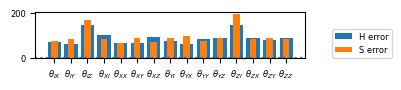

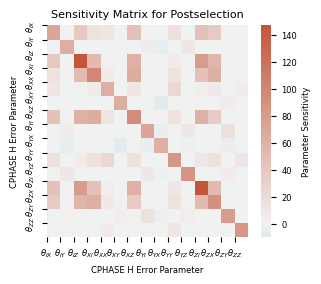

In [87]:
sensitivity_matrix_plot_small(sm[-15:,-15:], sms[-15:,-15:], title="Sensitivity Matrix for Postselection", filename=f'cultiv_postselection.pdf')

/var/folders/t7/7_fmy4y91wg47krr1d6v4kjw003x0b/T/ipykernel_31896/2354321534.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(3.25,1))


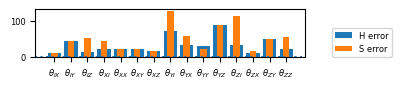

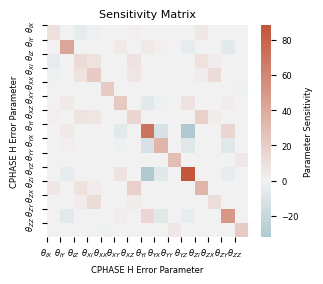

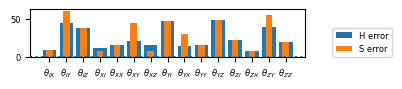

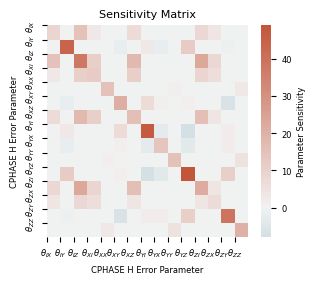

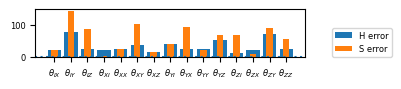

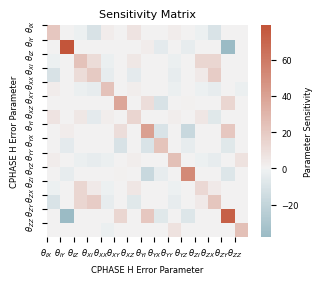

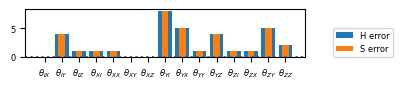

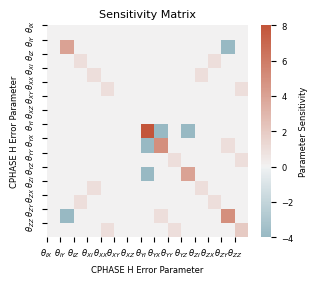

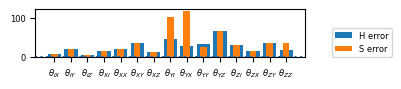

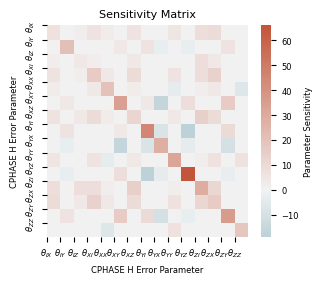

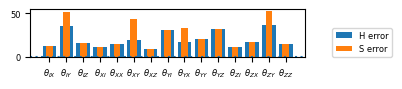

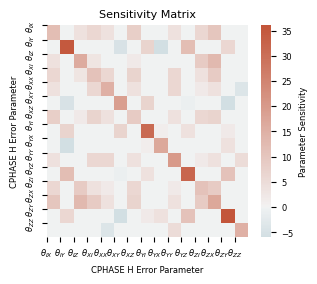

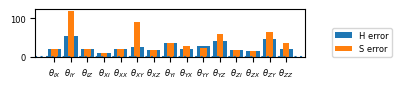

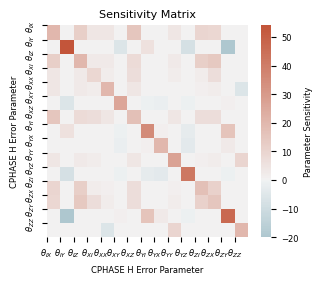

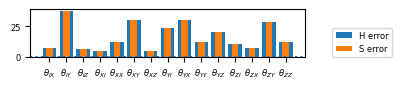

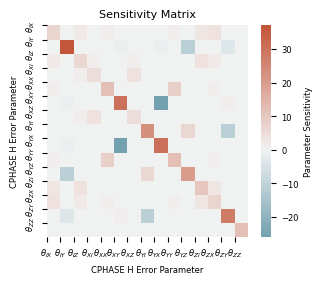

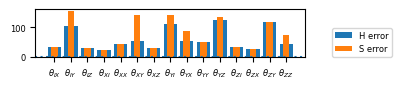

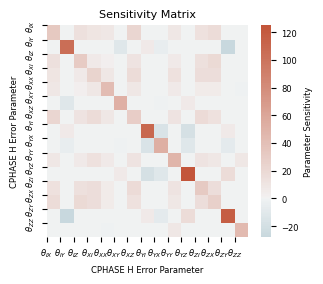

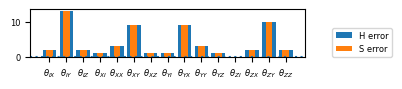

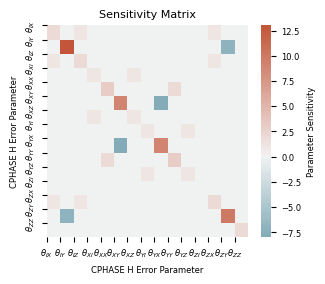

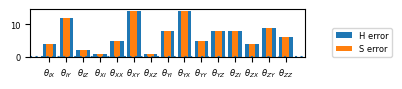

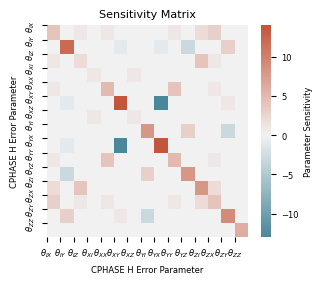

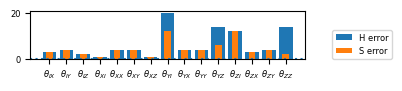

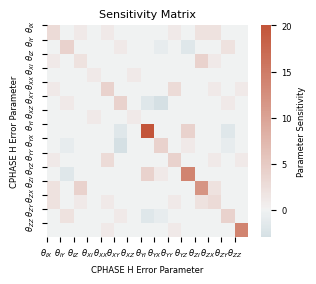

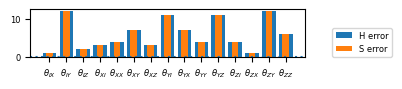

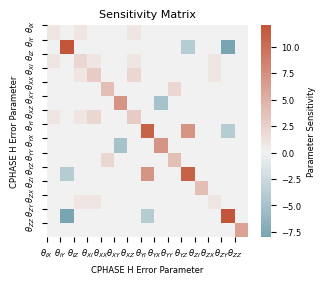

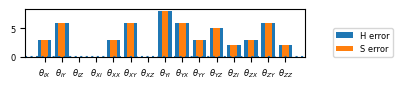

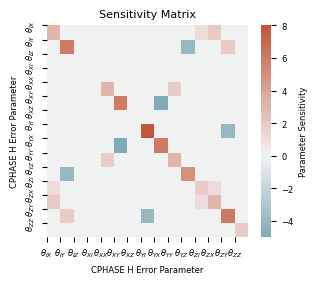

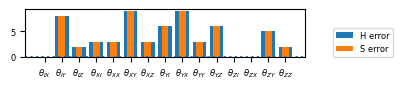

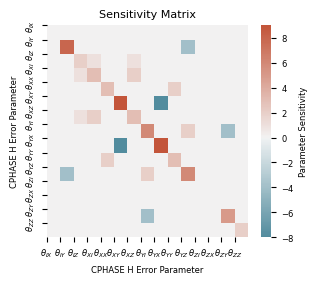

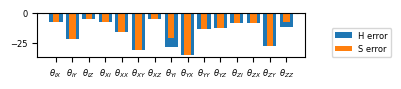

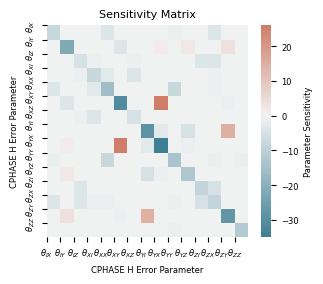

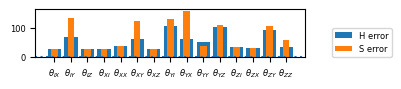

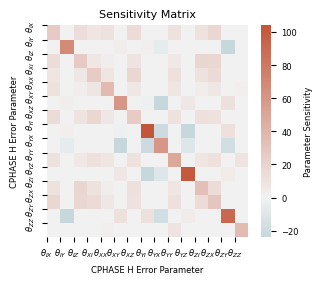

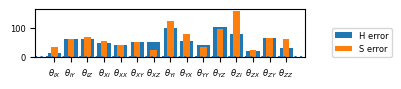

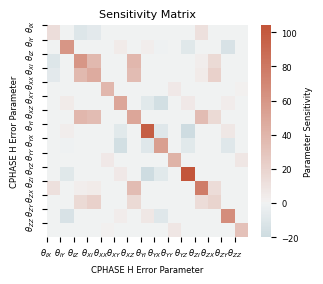

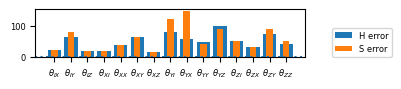

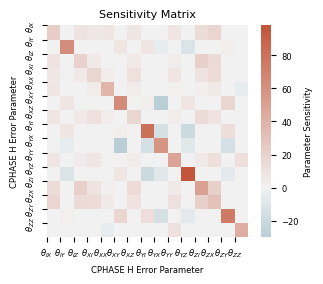

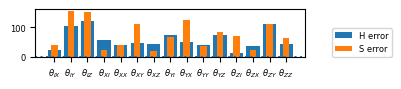

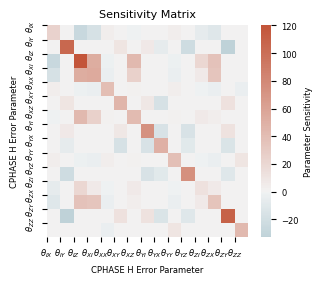

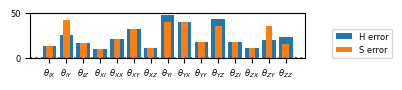

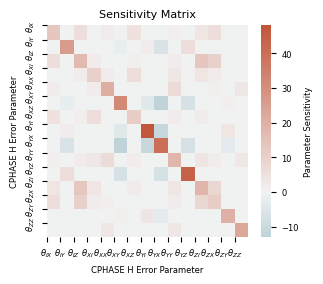

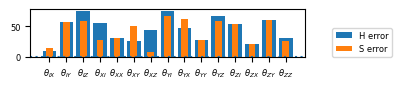

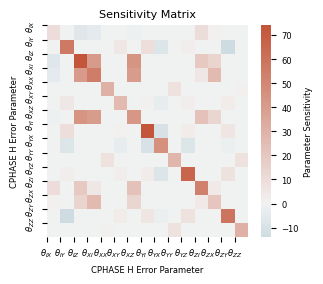

In [101]:
for i in range(len(dps)):
    sm = compute_event_sensitivity_matrix(svs, egp, serial_c, dps[i], tableau, show_progress=False)
    sms = compute_event_sensitivity_matrix(s_svs, egp, serial_c, dps[i], tableau, show_progress=False) 
    sensitivity_matrix_plot_small(sm[-15:,-15:], sms[-15:,-15:], title="Sensitivity Matrix",filename=f'cultiv_detector_{i}')
#am I dealing with signs incorrectly in the streamlined H code?

In [ ]:
sensitivity_matrix_plot(-1*sm[-15:,-15:], -1*sms[-15:,-15:], title="Sensitivity Matrix")

In [ ]:
sm = compute_event_sensitivity_matrix(svs, egp, serial_c, dps[-14], tableau, show_progress=False)
sms = compute_event_sensitivity_matrix(s_svs, egp, serial_c, dps[-14], tableau, show_progress=False) 

In [ ]:
sensitivity_matrix_plot(-1*sm[-15:,-15:], -1*sms[-15:,-15:], title="Sensitivity Matrix")